In [5]:
import cracknuts as cn

In [6]:
s1 = cn.cracker_f1('192.168.0.19')
s1.connect(force_update_bin=True, force_write_default_config=False)

In [ ]:
import random
import time
from cracknuts.cracker import serial


cmd_set_aes_enc_key = "01 00 00 00 00 00 00 10"
cmd_aes_enc = "01 02 00 00 00 00 00 10"

aes_key = "11 22 33 44 55 66 77 88 99 00 aa bb cc dd ee ff"
aes_data_len = 16

sample_length = 20000

def init(cracker):
    cracker.nut_voltage_enable()
    cracker.nut_voltage(3.3)
    cracker.nut_clock_enable()
    cracker.nut_clock_freq('8M')
    cracker.uart_io_enable()
    cracker.osc_sample_clock('48m')
    cracker.osc_sample_length(sample_length)
    cracker.osc_trigger_source('N')
    cracker.osc_analog_gain('B', 10)
    cracker.osc_trigger_level(0)
    cracker.osc_trigger_mode('E')
    cracker.osc_trigger_edge('U')
    cracker.uart_config(baudrate=serial.Baudrate.BAUDRATE_115200, bytesize=serial.Bytesize.EIGHTBITS, parity=serial.Parity.PARITY_NONE, stopbits=serial.Stopbits.STOPBITS_ONE)

    time.sleep(2)
    cmd = cmd_set_aes_enc_key + aes_key
    status, ret = cracker.uart_transmit_receive(cmd, timeout=1000, rx_count=6)

# def do(cracker, count):
#     plaintext_data = random.randbytes(aes_data_len)
#     tx_data = bytes.fromhex(cmd_aes_enc.replace(' ', '')) + plaintext_data
#     status, ret = cracker.uart_transmit_receive(tx_data, rx_count= 6 + aes_data_len, is_trigger=True)
    
#     return {
#         "plaintext": plaintext_data,
#         "ciphertext": ret[-aes_data_len:],
#         "key": bytes.fromhex(aes_key)
#     }

def do(cracker, count):
    # plaintext_data = random.randbytes(aes_data_len)
    plaintext_data = bytes.fromhex('AA BB CC DD EE FF 00 11 22 33 44 55 66 77 88 99')
    tx_data = bytes.fromhex(cmd_aes_enc.replace(' ', '')) + plaintext_data
    status, ret = cracker.uart_transmit_receive(tx_data, rx_count= 6 + aes_data_len, is_trigger=True)
    # print(ret.hex(' ') if ret else 'None')
    return {
        "plaintext": plaintext_data,
        "ciphertext": ret[-aes_data_len:],
        "key": bytes.fromhex(aes_key)
    }


def finish(cracker):
    ...
    # print('optional behavior')


acq = cn.simple_acq(s1, init, do)

p = cn.show_panel(acq)
p

In [ ]:
s1.get_firmware_version()

In [ ]:
s1.get_firmware_info()

In [ ]:
s1.change_ip('192.168.0.19', '255.255.255.0', '192.168.0.1')

In [ ]:
s1.register_write(base_address=0x43C1_0000, offset=0x1004, data=0)  ## VCC_ON

In [ ]:
# 
# 用户控制delay单位mS，1mS对应10_0000
# 电压控制精度0.1V，具体查表或公式

In [ ]:
# reset 平时不用
s1.register_write(base_address=0x43C1_0000, offset=0x100C, data=0b00001)  ## RESET

In [ ]:
# func_powerup_config(voltage, delay, enable) 5个电压，enable状态需要记录

s1.register_write(base_address=0x43C1_0000, offset=0x1010, data=(0 << 8) | (0xad)) ## VINT
s1.register_write(base_address=0x43C1_0000, offset=0x1018, data=(500000 << 8) | (0x96)) ## VAUX
s1.register_write(base_address=0x43C1_0000, offset=0x1014, data=(600000 << 8) | (0xD6)) ## VDDR 0xd6
s1.register_write(base_address=0x43C1_0000, offset=0x101c, data=(800000 << 8 ) | (0xFa))  ## VIO
s1.register_write(base_address=0x43C1_0000, offset=0x1020, data=(800000 << 8 ) | (0xFb))  ## VBAK

In [ ]:
# NutF_Power_on
s1.register_write(base_address=0x43C1_0000, offset=0x1004, data=1)  ## VCC_ON
time.sleep(0.5)
s1.register_write(base_address=0x43C1_0000, offset=0x1008, data=0b01101)  ## ENABLE BAK/IO/AUX/DDR/INT
# s1.register_write(base_address=0x43C1_0000, offset=0x1008, data=0b11111)  ## ENABLE BAK/IO/AUX/DDR/INT

In [ ]:
# NutF_Power_off
s1.register_write(base_address=0x43C1_0000, offset=0x1008, data=0b00000)  ## ENABLE

In [ ]:
s1.register_write(base_address=0x43C1_0000, offset=0x1020, data=(600000 << 8) | (0x1F)) 

In [ ]:
vint_voltage_set() # 先读再写寄存器，为了确认delay
vddr_voltage_set()
vaux_voltage_set()
vcco_voltage_set()
vbak_voltage_set()

In [ ]:
s1.register_write(base_address=0x43C1_0000, offset=0x1010, data=(20000 << 8) | (0xad)) ## VINT

In [ ]:
s1.register_write(base_address=0x43C1_0000, offset=0x1014, data=(600000 << 8) | (0x1D)) ## VDDR 0xd6

In [ ]:
s1.register_write(base_address=0x43C1_0000, offset=0x1018, data=(500000 << 8) | (0x96)) ## VAUX

In [ ]:
s1.register_write(base_address=0x43C1_0000, offset=0x101c, data=(800000 << 8 ) | (0xFa))  ## VIO

In [ ]:
s1.register_write(base_address=0x43C1_0000, offset=0x1020, data=(800000 << 8 ) | (0xFb))  ## VBAK

In [ ]:
s1.register_write(base_address=0x43C1_0000, offset=0x1004, data=1)  ## VCC_ON

In [ ]:
s1.register_write(base_address=0x43C1_0000, offset=0x1008, data=0b111111)  ## ENABLE

In [ ]:
s1.register_write(base_address=0x43C1_0000, offset=0x1010, data=(16 << 8) | (0x00 & 0xFF))

In [ ]:
s1.register_write(base_address=0x43C1_0000, offset=0x1010, data=(167_772_15 << 8) | (0xFF & 0xFF))

In [ ]:
s1.register_write(base_address=0x43C1_0000, offset=0x1020, data=(0 << 8) | (0xFF & 0xFF))
s1.register_write(base_address=0x43C1_0000, offset=0x1010, data=(167_772_15 << 8) | (0xFF & 0xFF))
s1.register_write(base_address=0x43C1_0000, offset=0x1014, data=(167_772_15 << 8) | (0xFF & 0xFF))
s1.register_write(base_address=0x43C1_0000, offset=0x1018, data=(167_772_15 << 8) | (0xFF & 0xFF))
s1.register_write(base_address=0x43C1_0000, offset=0x101c, data=(167_772_15 << 8) | (0xFF & 0xFF))
s1.register_write(base_address=0x43C1_0000, offset=0x1020, data=(167_772_15 << 8) | (0xFF & 0xFF))

In [ ]:
s1.register_write(base_address=0x43C1_0000, offset=0x1010, data=4096)
s1.register_write(base_address=0x43C1_0000, offset=0x1014, data=4096)
s1.register_write(base_address=0x43C1_0000, offset=0x1018, data=4096)
s1.register_write(base_address=0x43C1_0000, offset=0x101c, data=4096)
s1.register_write(base_address=0x43C1_0000, offset=0x1020, data=4096)

In [ ]:
print(s1.register_read(base_address=0x43C1_0000, offset=0x101c)[1].hex())
print(s1.register_read(base_address=0x43C1_0000, offset=0x1014)[1].hex())

In [ ]:
s1.osc_get_analog_wave()

In [ ]:
s1.register_read(base_address=0x43C2_0000, offset=0x00)   # 状态

In [ ]:
s1.register_write(base_address=0x43C2_0000, offset=0x000c, data=0x01)
s1.register_write(base_address=0x43C2_0000, offset=0x000c, data=0x00)

In [9]:
s1.register_write(base_address=0x43C2_0000, offset=0x0014, data=2000)

(0, None)

In [25]:
s1.osc_force()

(0, None)

In [26]:
_, w1 = s1.osc_get_analog_wave(channel=1, offset=0, sample_count=2000)

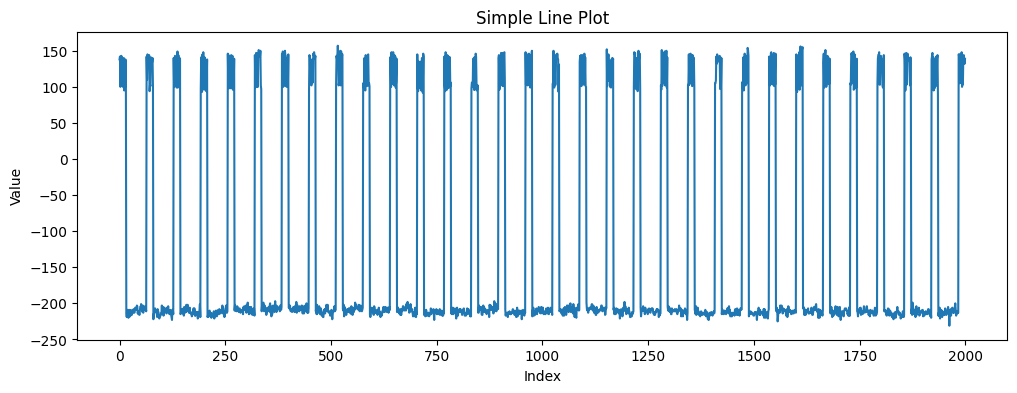

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(w1)

# 添加标题和标签
plt.title("Simple Line Plot")
plt.xlabel("Index")
plt.ylabel("Value")

# 显示图像
plt.show()

In [30]:
s1.osc_force()

(0, None)

In [31]:
_, w2 = s1.osc_get_analog_wave(channel=1, offset=0, sample_count=2000)

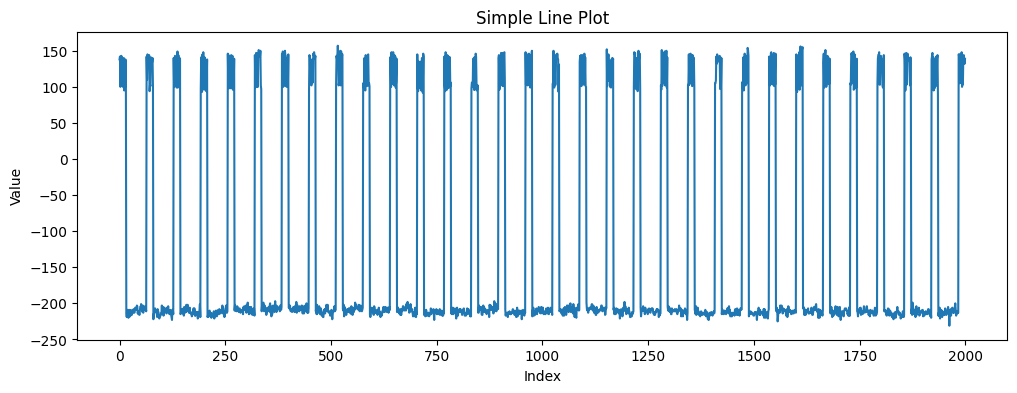

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(w1)

# 添加标题和标签
plt.title("Simple Line Plot")
plt.xlabel("Index")
plt.ylabel("Value")

# 显示图像
plt.show()

In [24]:
w = w1